In [23]:
# import required libraries
import kagglehub
from pathlib import Path
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
# load data set
donwloadPath = kagglehub.dataset_download('lespin/house-prices-dataset')
dataPath = Path(donwloadPath)

print(f'Contents of {dataPath}:')
for item in dataPath.iterdir():
    print(f' - {item.name} ({'Folder' if item.is_dir() else 'File'})')




-- Housing : First few Rows --


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


-- Housing Shape: (1460, 81) --

-- Housing Data Type Count --
str        43
int64      35
float64     3
Name: count, dtype: int64

-- Housing Info --
<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

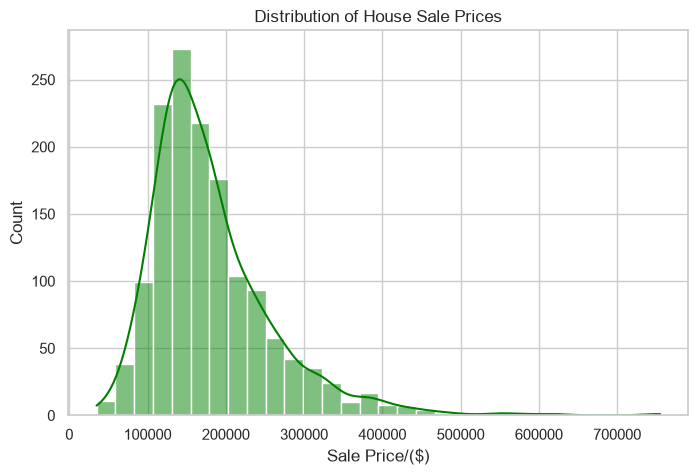

In [14]:
# Inspect data set
dfHousing = pd.read_csv(f'{donwloadPath}/train.csv')

# print first 5 lines
print('-- Housing : First few Rows --')
display(dfHousing.head())

# check data set shape
print(f'-- Housing Shape: {dfHousing.shape} --')

# check available data types
print('\n-- Housing Data Type Count --')
print(dfHousing.dtypes.value_counts())

# check data counts (checking missing values)
print('\n-- Housing Info --')
dfHousing.info()

# get statistical summary
print('\n-- Housing Targer Summary (Sales Price) --')
display(dfHousing['SalePrice'].describe())

# visualize distribution
sns.set_theme(style='whitegrid')
plt.figure(figsize=(8,5))
sns.histplot(dfHousing['SalePrice'], kde=True, color='green', bins=30)
plt.title('Distribution of House Sale Prices')
plt.xlabel('Sale Price/($)')
plt.ylabel('Count')
plt.show()

In [ ]:
# Handle missing values

# Check missing values
print('\n-- Missing values before hangling --')
missingData = dfHousing.isnull().sum()
print(missingData[missingData > 0])

# replace with median value
if 'LotFrontage' in dfHousing.columns:
    lotFrontageMedian = dfHousing['LotFrontage'].median()
    dfHousing['LotFrontage'] = dfHousing['LotFrontage'].fillna(lotFrontageMedian)
    print(f"\nFilled missing 'LotFrontage' values with meadian: {lotFrontageMedian}")

# replace with frequent value
if 'Electrical' in dfHousing.columns:
    electricalMode = dfHousing['Electrical'].mode()[0]
    dfHousing['Electrical'] = dfHousing['Electrical'].fillna(electricalMode)
    print(f"Filled missing 'Electrical' values with mode: {electricalMode}")

# replace with 0
if 'MasVnrArea' in dfHousing.columns:
    dfHousing['MasVnrArea'] = dfHousing['MasVnrArea'].fillna(0)
    print("Filled missing 'MasVnrArea' values with value: 0")


# replace all other missing string values with 'None'
attributes = ['Alley', 'MasVnrType', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PoolQC', 'Fence', 'MiscFeature']
for attr in attributes:
    if attr in dfHousing.columns:
        dfHousing[attr] = dfHousing[attr].fillna('None')
        print(f"Filled missing '{attr}' values with value: 'None'")       

# add hasGarage attribute
dfHousing['HasGarage'] = (dfHousing['GarageType'] != 'None').astype(int)

if 'GarageYrBlt' in dfHousing.columns:
    dfHousing['GarageYrBlt'] = dfHousing['GarageYrBlt'].fillna(0)
    print("Filled missing 'GarageYrBlt' values with value: 0")

# Validate missing values
print('\n-- Missing values after hangling --')
missingData = dfHousing.isnull().sum()
print(missingData[missingData > 0])

print(dfHousing.shape)




-- Missing values before hangling --
GarageYrBlt    81
dtype: int64

Filled missing 'LotFrontage' values with meadian: 69.0
Filled missing 'Electrical' values with mode: SBrkr
Filled missing 'MasVnrArea' values with value: 0
Filled missing 'Alley' values with value: 'None'
Filled missing 'MasVnrType' values with value: 'None'
Filled missing 'BsmtQual' values with value: 'None'
Filled missing 'BsmtCond' values with value: 'None'
Filled missing 'BsmtExposure' values with value: 'None'
Filled missing 'BsmtFinType1' values with value: 'None'
Filled missing 'BsmtFinType2' values with value: 'None'
Filled missing 'FireplaceQu' values with value: 'None'
Filled missing 'GarageType' values with value: 'None'
Filled missing 'GarageFinish' values with value: 'None'
Filled missing 'GarageQual' values with value: 'None'
Filled missing 'GarageCond' values with value: 'None'
Filled missing 'PoolQC' values with value: 'None'
Filled missing 'Fence' values with value: 'None'
Filled missing 'MiscFeature

KeyError: True